# DDPM Example Usage

This script walks through the full workflow:
setup → train → save/load → generate → plot.
Make sure the `ddpm/` package folder is in the same directory (or on your PYTHONPATH).

cd "C:\Users\lodik\Documents\programming\diffusion-models-project-main"

git status

git checkout main

git add -A
git commit -m "Overwrite repo with local files"

git push origin main
git push upstream main:lodi-time-and-attention

In [1]:
# --- Setup repo in Colab ---
%cd /content

import os
import sys

repo_path = "/content/ddpm-project-lodi"

if not os.path.exists(repo_path):
    !git clone https://github.com/LodiHendrikKamman/ddpm-project-lodi.git

%cd /content/ddpm-project-lodi
!git pull
!pip install -r requirements.txt

# Make sure Python can find the repo/package
if repo_path not in sys.path:
    sys.path.append(repo_path)

[WinError 2] The system cannot find the file specified: '/content'
c:\Users\lodik\Documents\programming\diffusion-models-project-main
[WinError 3] The system cannot find the path specified: '/content/ddpm-project-lodi'
c:\Users\lodik\Documents\programming\diffusion-models-project-main


fatal: destination path 'ddpm-project-lodi' already exists and is not an empty directory.


Already up to date.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# --- Imports ---
import torch

from ddpm import NoiseScheduler, UNet, train, find_lr, generate_image, noisy_image
from ddpm.dataset import load_mnist, get_noisy_loaders
from ddpm.utils import load_unet, channel_list, model_name, path_name
from ddpm.viz import plot_generated
import random
import numpy as np

def set_seed(seed=42, deterministic=True):
    import random
    import numpy as np
    import torch

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Imports worked!")

Using device: cuda
Imports worked!


## 1. Noise scheduler and data

The scheduler defines the beta schedule and handles the forward noising process.
T=1000 steps, linearly spaced betas from 1e-4 to 0.02 (Ho et al. defaults).

In [3]:
set_seed(42)
scheduler = NoiseScheduler(T=1000, beta_start=1e-4, beta_end=0.02).to(device)
train_set, test_set = load_mnist()

### Training on a single digit

Pass a filter function to get_noisy_loaders_filtered to restrict the dataset.
Here we train on zeros only, but any (dataset -> Subset) function works.

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.2467 | test loss: 0.1170


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 29 | train loss: 0.0285 | test loss: 0.0294


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 30 | train loss: 0.0287 | test loss: 0.0264
Early stopping at epoch 30


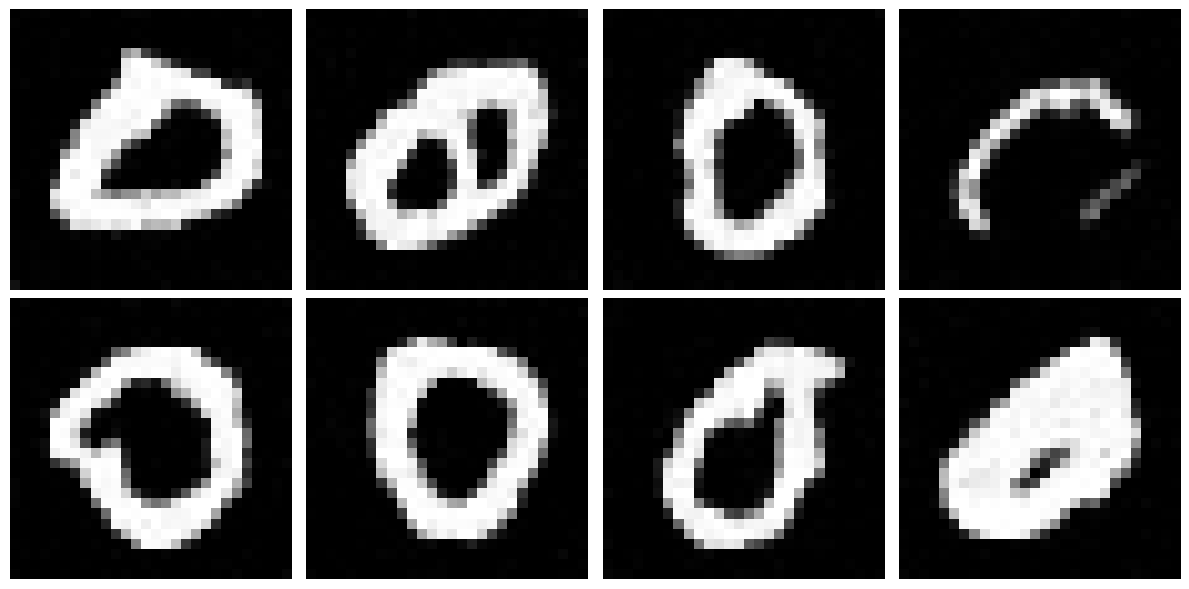

In [4]:
from ddpm.dataset import get_noisy_loaders_filtered, zeros_only

# unet_zeros = load_unet( "zeros_only.pkl", channels=channel_list(64), convs_per_level=2, num_heads_att=4, time_emb_dim=128, time_emb_base_dim=32,)

set_seed(42)
train_loader_zeros, test_loader_zeros = get_noisy_loaders_filtered( train_set, test_set, scheduler, filter_fn=zeros_only, batch_size=32)

set_seed(42)
unet_zeros = UNet( channels=channel_list(64), convs_per_level=2, num_heads_att=4, time_emb_dim=128, time_emb_base_dim=32,).to(device)

set_seed(123)
train_losses, test_losses = train( unet_zeros, train_loader_zeros, test_loader_zeros, epochs=50, lr=2e-4, weight_decay=1e-6,early_stopping_patience=10, save_path='zeros_only.pkl', use_time=True)


set_seed(999)
x = generate_image(unet_zeros, scheduler, n_images=8, stochasticity=1.0, use_time=True,)
plot_generated(x, ncol=4)